In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve, precision_recall_curve, auc
from sklearn.decomposition import PCA

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["font.size"] = 11

PALETTE = {
    "pink": "#FF4D8D",
    "purple": "#7C4DFF",
    "cyan": "#00C2FF",
    "green": "#00C853",
    "orange": "#FF9100",
    "red": "#FF3D71",
    "blue": "#2979FF",
    "gold": "#FFD740",
    "teal": "#00BFA5",
    "dark": "#202124"
}

tf.keras.utils.set_random_seed(SEED)
print(tf.__version__)

2.20.0


In [2]:
subjects = [
    "the movie", "the series", "the book", "the phone", "the laptop",
    "the headphones", "the camera", "the restaurant", "the hotel",
    "the game", "the course", "the app", "the website", "the service",
    "the product", "the delivery", "the concert", "the café",
    "the keyboard", "the monitor"
]

positive_patterns = [
    "was excellent and genuinely enjoyable",
    "was a wonderful experience from start to finish",
    "felt polished, thoughtful, and easy to love",
    "worked smoothly and exceeded my expectations",
    "was impressive, reliable, and worth the money",
    "made everything feel simple and satisfying",
    "was beautifully designed and pleasant to use",
    "delivered exactly what I hoped for",
    "was surprisingly good and kept getting better",
    "felt fresh, energetic, and memorable",
    "was comfortable, practical, and dependable",
    "had great quality and excellent attention to detail",
    "was fast, responsive, and highly satisfying",
    "looked fantastic and performed even better",
    "was fun, engaging, and easy to recommend",
    "gave me a genuinely positive experience",
    "was better than expected in almost every way",
    "felt premium without becoming complicated",
    "was a smart purchase and a joy to use",
    "left me very happy with the final result"
]

negative_patterns = [
    "was disappointing and frustrating from start to finish",
    "felt poorly made and difficult to enjoy",
    "worked badly and failed to meet my expectations",
    "was a waste of time and money",
    "felt slow, unreliable, and annoying",
    "had weak quality and careless design",
    "looked promising but turned out to be a mess",
    "was uncomfortable and surprisingly difficult to use",
    "kept causing problems when I needed it most",
    "felt outdated, confusing, and frustrating",
    "was nowhere near the quality I expected",
    "had terrible performance and poor value",
    "left me disappointed after only a short time",
    "was noisy, clumsy, and hard to recommend",
    "made a simple task unnecessarily difficult",
    "felt rushed and full of obvious mistakes",
    "was one of the more frustrating experiences I have had",
    "did not justify the price at all",
    "became annoying very quickly",
    "left me unhappy with the final result"
]

positive_context = [
    "I would gladly choose it again.",
    "The whole experience felt smooth and rewarding.",
    "It is easy to recommend to other people.",
    "I am impressed by how consistent it was.",
    "It delivered more value than I expected.",
    "I would happily use it again next week."
]

negative_context = [
    "I would avoid it next time.",
    "The whole experience became exhausting.",
    "I cannot recommend it in its current form.",
    "I am disappointed by how inconsistent it was.",
    "It delivered far less value than I expected.",
    "I would not choose it again."
]

positive_reviews = []
negative_reviews = []

for i, subject in enumerate(subjects):
    for j, pattern in enumerate(positive_patterns):
        context = positive_context[(i + j) % len(positive_context)]
        positive_reviews.append(f"{subject.capitalize()} {pattern}. {context}")
    for j, pattern in enumerate(negative_patterns):
        context = negative_context[(i + 2 * j) % len(negative_context)]
        negative_reviews.append(f"{subject.capitalize()} {pattern}. {context}")

extra_positive = [
    "I expected an average experience, but it was much better than I imagined.",
    "There were a few tiny issues, yet the overall experience was excellent.",
    "The quality surprised me in the best possible way.",
    "Everything from the first interaction to the final result felt professional.",
    "The small details made the experience feel special rather than ordinary.",
    "I kept finding reasons to enjoy it more as I used it.",
    "The performance stayed stable even when I pushed it harder.",
    "This is the kind of experience that earns trust quickly.",
    "The interface was clean, intuitive, and genuinely pleasant.",
    "The result felt refined instead of rushed or unfinished."
]

extra_negative = [
    "I expected a decent experience, but it was much worse than I imagined.",
    "There were a few positives, yet the overall experience was poor.",
    "The quality surprised me in the worst possible way.",
    "Everything from the first interaction to the final result felt careless.",
    "The small details made the experience feel cheap rather than polished.",
    "I kept finding more problems the longer I used it.",
    "The performance became unstable as soon as I pushed it harder.",
    "This is the kind of experience that quickly destroys trust.",
    "The interface was cluttered, confusing, and frustrating.",
    "The result felt unfinished instead of refined."
]

positive_reviews.extend(extra_positive * 4)
negative_reviews.extend(extra_negative * 4)

df = pd.DataFrame({
    "text": positive_reviews + negative_reviews,
    "label": [1] * len(positive_reviews) + [0] * len(negative_reviews)
})

df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
df["sentiment"] = df["label"].map({0: "Negative", 1: "Positive"})
df["word_count"] = df["text"].str.split().str.len()

print(df.shape)
display(df.head(12))

(880, 4)


,text,label,sentiment,word_count
0,The concert had great quality and excellent at...,1,Positive,18
1,The website delivered exactly what I hoped for...,1,Positive,15
2,The café was nowhere near the quality I expect...,0,Negative,14
3,The delivery was better than expected in almos...,1,Positive,17
4,The course gave me a genuinely positive experi...,1,Positive,15
5,The website was disappointing and frustrating ...,0,Negative,16
6,The restaurant had weak quality and careless d...,0,Negative,14
7,The series worked badly and failed to meet my ...,0,Negative,16
8,The keyboard felt rushed and full of obvious m...,0,Negative,15
9,The series left me very happy with the final r...,1,Positive,18


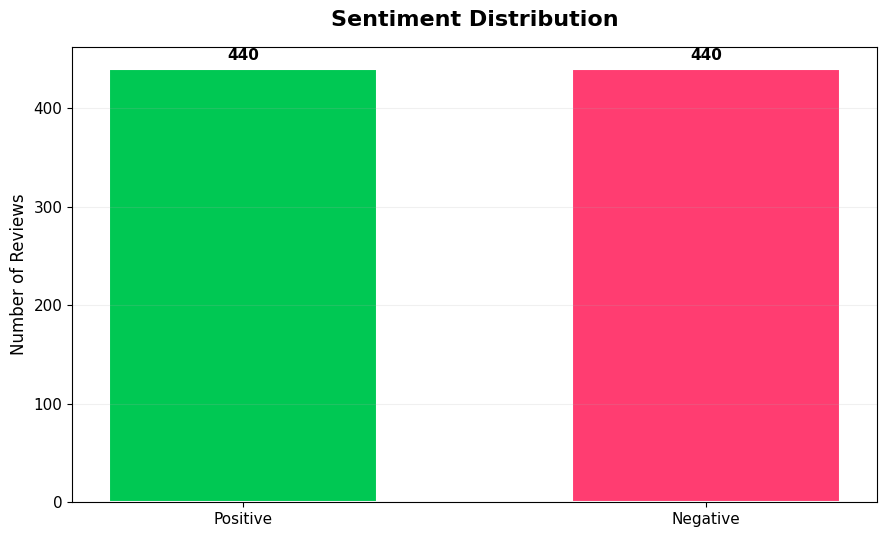

In [3]:
counts = df["sentiment"].value_counts().reindex(["Positive", "Negative"])

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(counts.index, counts.values, color=[PALETTE["green"], PALETTE["red"]], width=0.58, edgecolor="white", linewidth=1.5)
ax.set_title("Sentiment Distribution", pad=15)
ax.set_ylabel("Number of Reviews")
ax.grid(axis="y", alpha=0.18)
for bar, value in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + max(counts.values) * 0.02, f"{value}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

/tmp/ipykernel_4101/3915884031.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


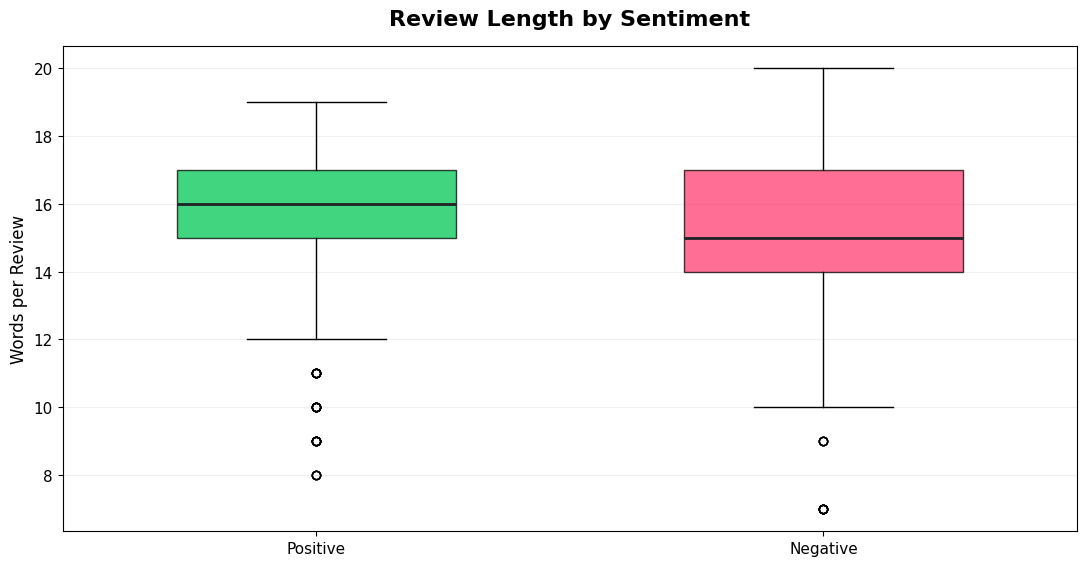

In [4]:
fig, ax = plt.subplots(figsize=(11, 5.8))
parts = [
    df.loc[df["label"] == 1, "word_count"].values,
    df.loc[df["label"] == 0, "word_count"].values
]
bp = ax.boxplot(
    parts,
    labels=["Positive", "Negative"],
    patch_artist=True,
    widths=0.55,
    medianprops={"color": PALETTE["dark"], "linewidth": 2}
)
for patch, color in zip(bp["boxes"], [PALETTE["green"], PALETTE["red"]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax.set_title("Review Length by Sentiment", pad=15)
ax.set_ylabel("Words per Review")
ax.grid(axis="y", alpha=0.18)
plt.tight_layout()
plt.show()

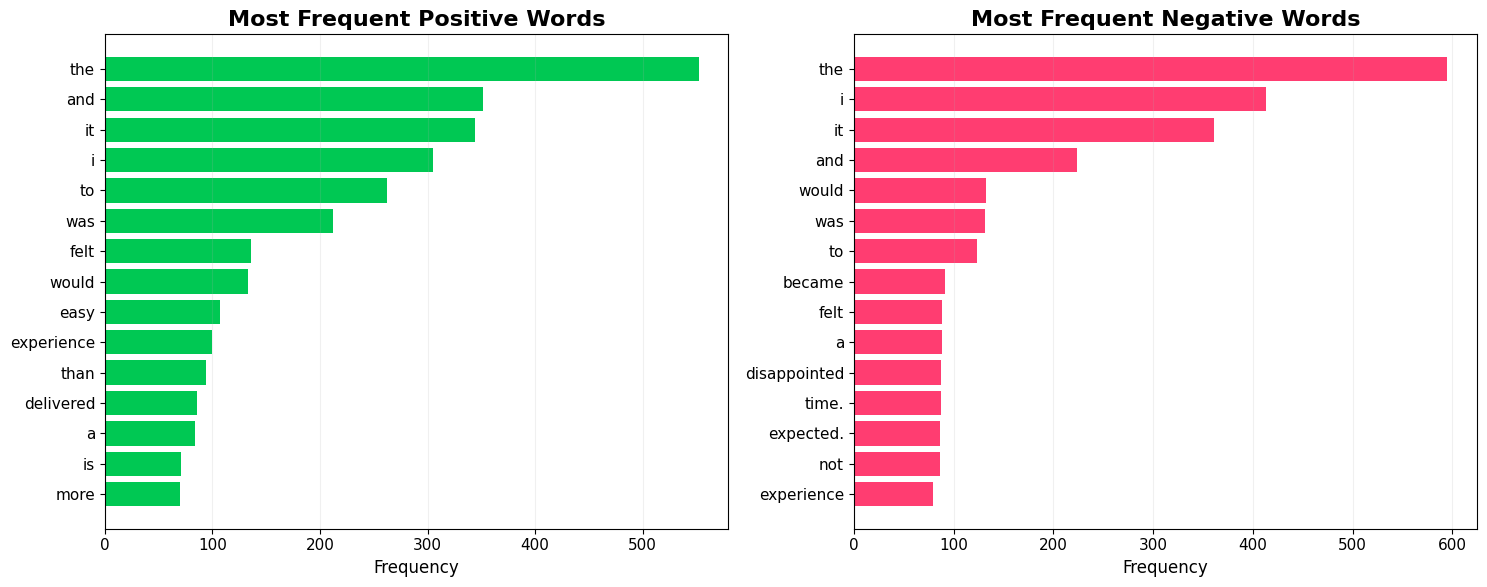

In [5]:
all_words = " ".join(df["text"]).lower().split()
positive_words = " ".join(df.loc[df["label"] == 1, "text"]).lower().split()
negative_words = " ".join(df.loc[df["label"] == 0, "text"]).lower().split()

def top_words(words, n=15):
    return pd.Series(words).value_counts().head(n).sort_values()

pos_top = top_words(positive_words)
neg_top = top_words(negative_words)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(pos_top.index, pos_top.values, color=PALETTE["green"])
axes[0].set_title("Most Frequent Positive Words")
axes[0].set_xlabel("Frequency")
axes[0].grid(axis="x", alpha=0.18)

axes[1].barh(neg_top.index, neg_top.values, color=PALETTE["red"])
axes[1].set_title("Most Frequent Negative Words")
axes[1].set_xlabel("Frequency")
axes[1].grid(axis="x", alpha=0.18)

plt.tight_layout()
plt.show()

In [6]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df["label"]
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=SEED,
    stratify=train_df["label"]
)

X_train = train_df["text"].values
y_train = train_df["label"].values.astype("float32")
X_val = val_df["text"].values
y_val = val_df["label"].values.astype("float32")
X_test = test_df["text"].values
y_test = test_df["label"].values.astype("float32")

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 563
Validation: 141
Test: 176


In [7]:
MAX_TOKENS = 4000
SEQUENCE_LENGTH = 45

vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=SEQUENCE_LENGTH,
    standardize="lower_and_strip_punctuation"
)

vectorizer.adapt(tf.data.Dataset.from_tensor_slices(X_train).batch(32))

vocabulary = np.array(vectorizer.get_vocabulary())
print("Vocabulary size:", len(vocabulary))
print(vocabulary[:40])

Vocabulary size: 255
['' '[UNK]' 'the' 'i' 'it' 'and' 'was' 'to' 'would' 'felt' 'again'
 'expected' 'than' 'a' 'experience' 'recommend' 'delivered' 'value'
 'choose' 'next' 'how' 'by' 'am' 'use' 'time' 'whole' 'easy' 'in' 'not'
 'more' 'disappointed' 'had' 'me' 'became' 'of' 'gladly' 'avoid'
 'inconsistent' 'better' 'quality']


In [8]:
sample_text = X_train[0]
encoded_sample = vectorizer(tf.constant([sample_text])).numpy()[0]

print(sample_text)
print(encoded_sample[:30])

The app was surprisingly good and kept getting better. The whole experience felt smooth and rewarding.
[  2  80   6  77 135   5  62 136  38   2  25  14   9  56   5  57   0   0
   0   0   0   0   0   0   0   0   0   0   0   0]


In [9]:
embedding_dim = 64
gru_units = 64

inputs = tf.keras.Input(shape=(), dtype=tf.string, name="text")
x = vectorizer(inputs)
x = tf.keras.layers.Embedding(
    input_dim=len(vocabulary),
    output_dim=embedding_dim,
    name="embedding"
)(x)
x = tf.keras.layers.SpatialDropout1D(0.20)(x)
x = tf.keras.layers.GRU(
    gru_units,
    return_sequences=True,
    dropout=0.18,
    recurrent_dropout=0.0,
    name="gru_sequence"
)(x)
x = tf.keras.layers.GRU(
    32,
    dropout=0.18,
    recurrent_dropout=0.0,
    name="gru_final"
)(x)
x = tf.keras.layers.Dense(32, activation="relu", name="dense_features")(x)
x = tf.keras.layers.Dropout(0.25)(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid", name="sentiment")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-3),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text (InputLayer)               │ (None)                 │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization              │ (None, 45)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 45, 64)         │        16,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 45, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_sequence (GRU)              │ (None, 45, 64)         │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_final (GRU)                 │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_features (Dense)          │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sentiment (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,777 (202.25 KB)

 Trainable params: 51,777 (202.25 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-5
    )
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=16,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/16
36/36 ━━━━━━━━━━━━━━━━━━━━ 22s 34ms/step - accuracy: 0.4671 - auc: 0.4628 - loss: 0.6960 - precision: 0.4625 - recall: 0.3936 - val_accuracy: 0.5035 - val_auc: 0.5000 - val_loss: 0.6931 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0020
Epoch 2/16
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.4920 - auc: 0.4842 - loss: 0.6960 - precision: 0.4844 - recall: 0.2199 - val_accuracy: 0.5035 - val_auc: 0.5000 - val_loss: 0.6932 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0020
Epoch 3/16
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.5027 - auc: 0.4819 - loss: 0.6951 - precision: 0.5060 - recall: 0.2979 - val_accuracy: 0.5035 - val_auc: 0.5000 - val_loss: 0.6931 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0020
Epoch 4/16
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.4813 - auc: 0.4875 - loss: 0.6950 - precision: 0.4766 - recall: 0.3617 - val_accuracy: 0.5035 - val_auc: 0.5000 - v

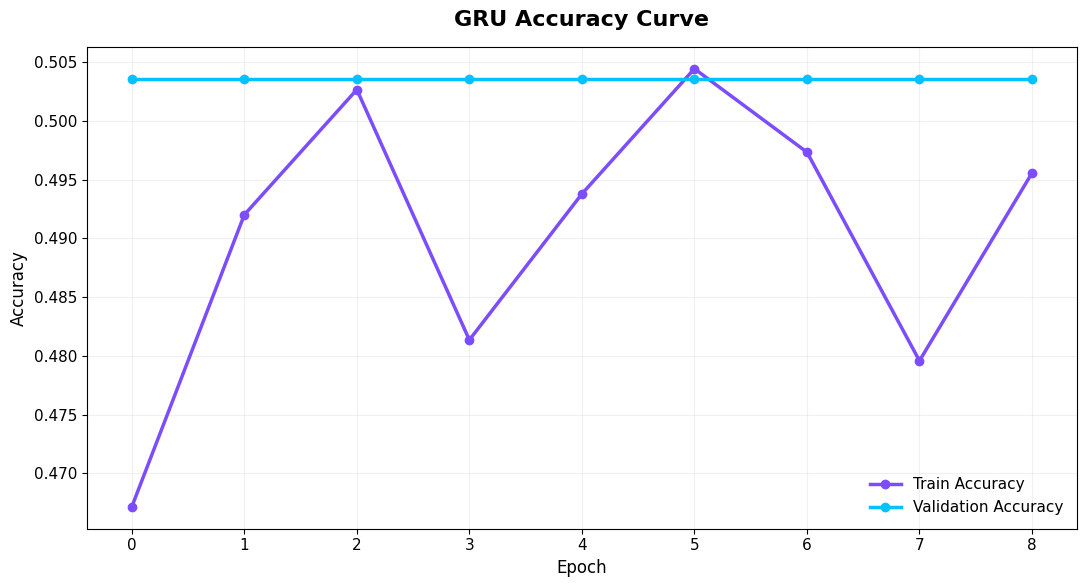

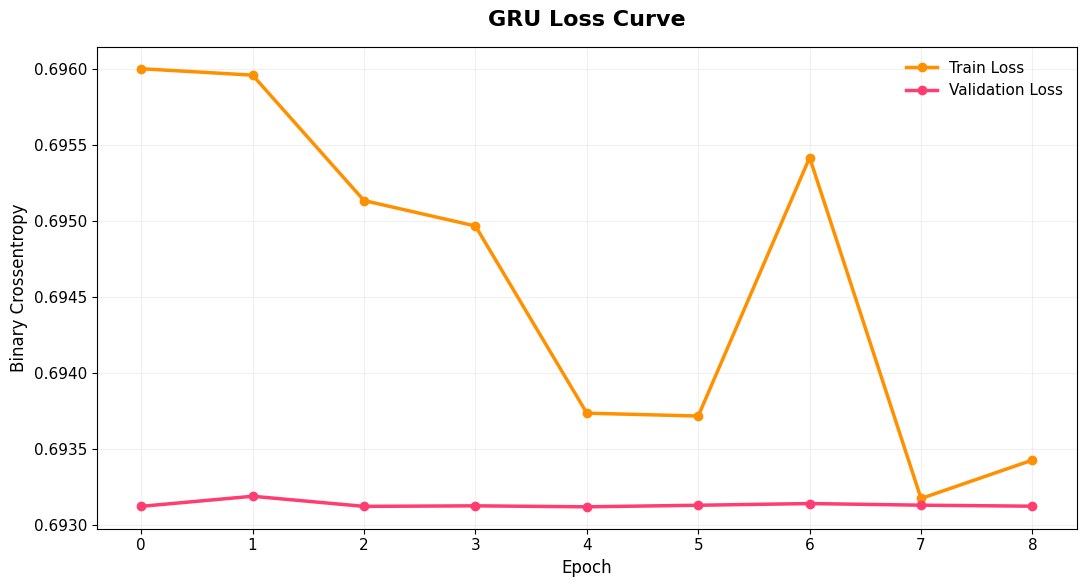

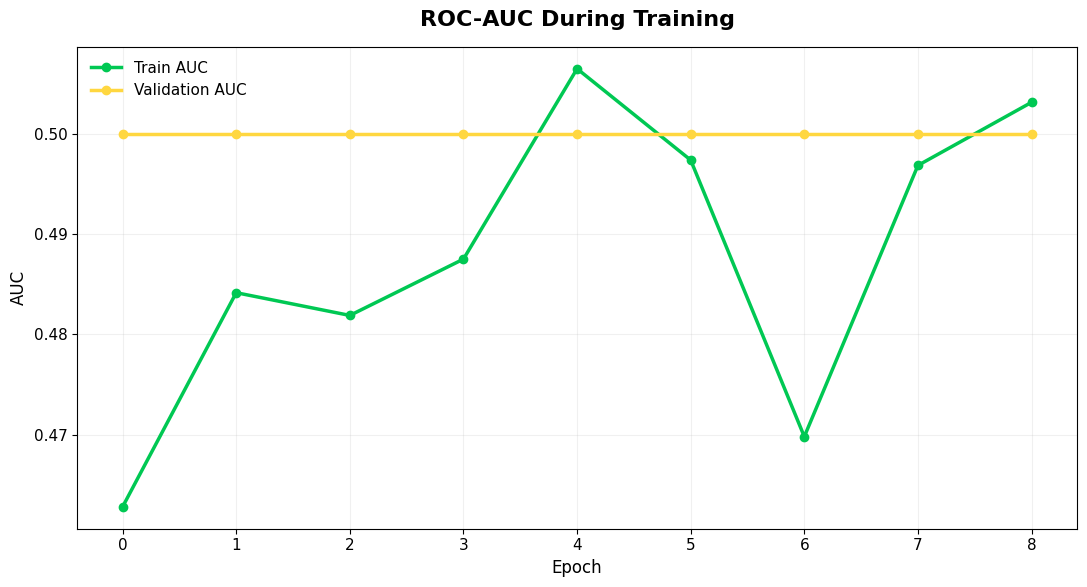

In [11]:
history_df = pd.DataFrame(history.history)

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(history_df["accuracy"], marker="o", linewidth=2.5, color=PALETTE["purple"], label="Train Accuracy")
ax.plot(history_df["val_accuracy"], marker="o", linewidth=2.5, color=PALETTE["cyan"], label="Validation Accuracy")
ax.set_title("GRU Accuracy Curve", pad=15)
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.legend(frameon=False)
ax.grid(alpha=0.18)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(history_df["loss"], marker="o", linewidth=2.5, color=PALETTE["orange"], label="Train Loss")
ax.plot(history_df["val_loss"], marker="o", linewidth=2.5, color=PALETTE["red"], label="Validation Loss")
ax.set_title("GRU Loss Curve", pad=15)
ax.set_xlabel("Epoch")
ax.set_ylabel("Binary Crossentropy")
ax.legend(frameon=False)
ax.grid(alpha=0.18)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(history_df["auc"], marker="o", linewidth=2.5, color=PALETTE["green"], label="Train AUC")
ax.plot(history_df["val_auc"], marker="o", linewidth=2.5, color=PALETTE["gold"], label="Validation AUC")
ax.set_title("ROC-AUC During Training", pad=15)
ax.set_xlabel("Epoch")
ax.set_ylabel("AUC")
ax.legend(frameon=False)
ax.grid(alpha=0.18)
plt.tight_layout()
plt.show()

In [12]:
test_results = model.evaluate(X_test, y_test, verbose=0, return_dict=True)
metrics_df = pd.DataFrame({
    "Metric": list(test_results.keys()),
    "Score": list(test_results.values())
})

display(metrics_df.style.format({"Score": "{:.4f}"}))

,Metric,Score
0,accuracy,0.5000
1,auc,0.5000
2,loss,0.6932
3,precision,0.0000
4,recall,0.0000


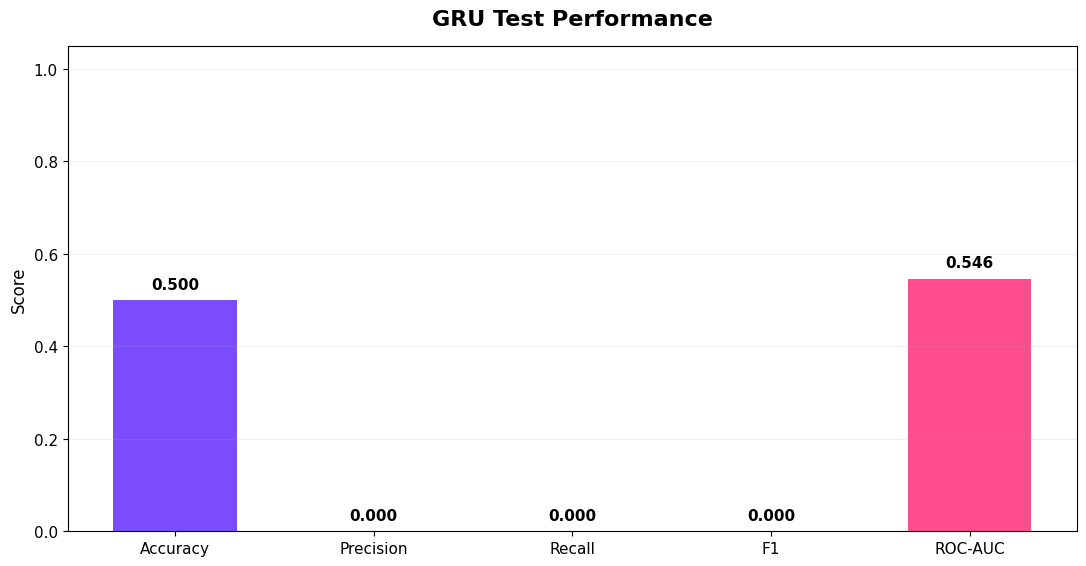

              precision    recall  f1-score   support

    Negative     0.5000    1.0000    0.6667        88
    Positive     0.0000    0.0000    0.0000        88

    accuracy                         0.5000       176
   macro avg     0.2500    0.5000    0.3333       176
weighted avg     0.2500    0.5000    0.3333       176



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [13]:
test_probabilities = model.predict(X_test, verbose=0).ravel()
test_predictions = (test_probabilities >= 0.5).astype(int)

metrics = {
    "Accuracy": accuracy_score(y_test, test_predictions),
    "Precision": precision_score(y_test, test_predictions, zero_division=0),
    "Recall": recall_score(y_test, test_predictions, zero_division=0),
    "F1": f1_score(y_test, test_predictions, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, test_probabilities)
}

metric_names = list(metrics.keys())
metric_values = list(metrics.values())

fig, ax = plt.subplots(figsize=(11, 5.8))
bars = ax.bar(metric_names, metric_values, color=[
    PALETTE["purple"], PALETTE["cyan"], PALETTE["green"], PALETTE["orange"], PALETTE["pink"]
], width=0.62)
ax.set_ylim(0, 1.05)
ax.set_title("GRU Test Performance", pad=15)
ax.set_ylabel("Score")
ax.grid(axis="y", alpha=0.18)
for bar, value in zip(bars, metric_values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.025, f"{value:.3f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

print(classification_report(y_test, test_predictions, target_names=["Negative", "Positive"], digits=4))

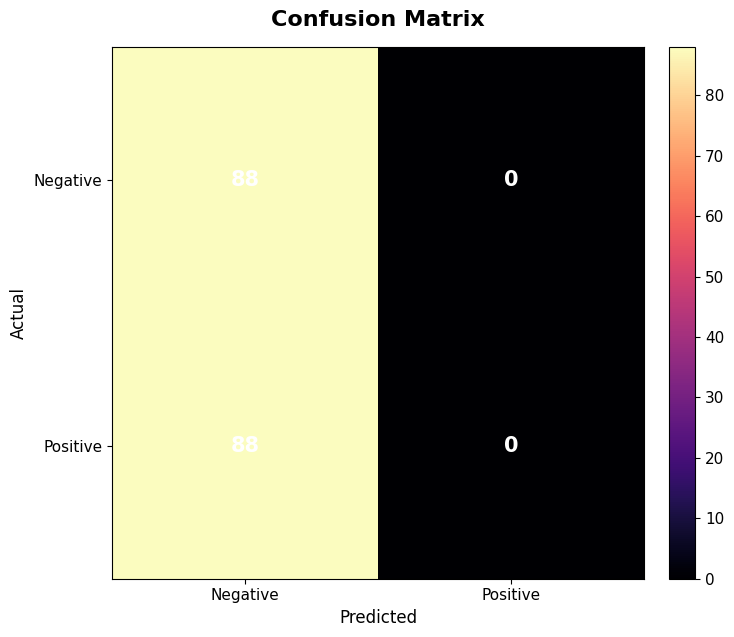

In [14]:
cm = confusion_matrix(y_test, test_predictions)

fig, ax = plt.subplots(figsize=(7.5, 6.5))
image = ax.imshow(cm, cmap="magma")
ax.set_title("Confusion Matrix", pad=15)
ax.set_xticks([0, 1], ["Negative", "Positive"])
ax.set_yticks([0, 1], ["Negative", "Positive"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="white", fontsize=15, fontweight="bold")

fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

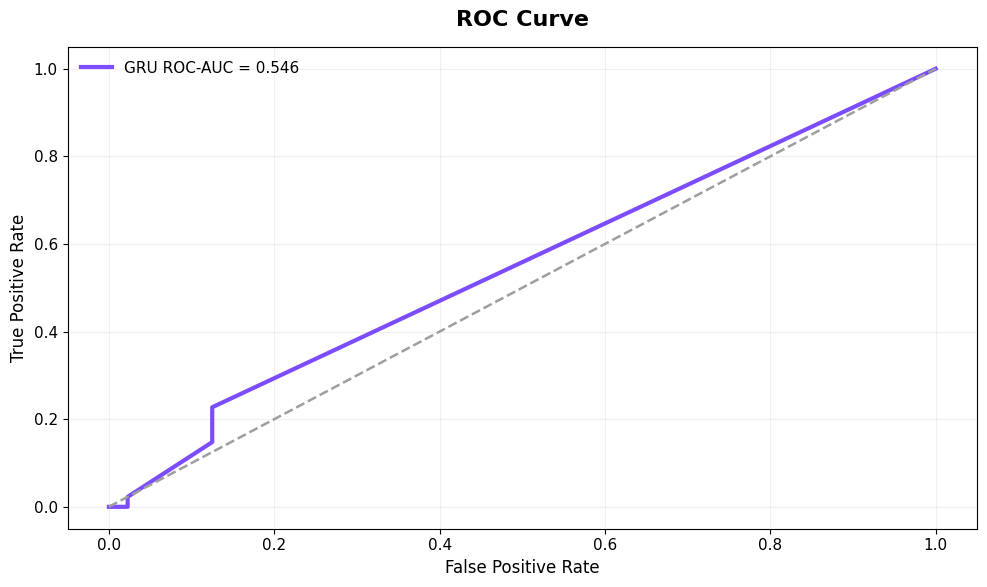

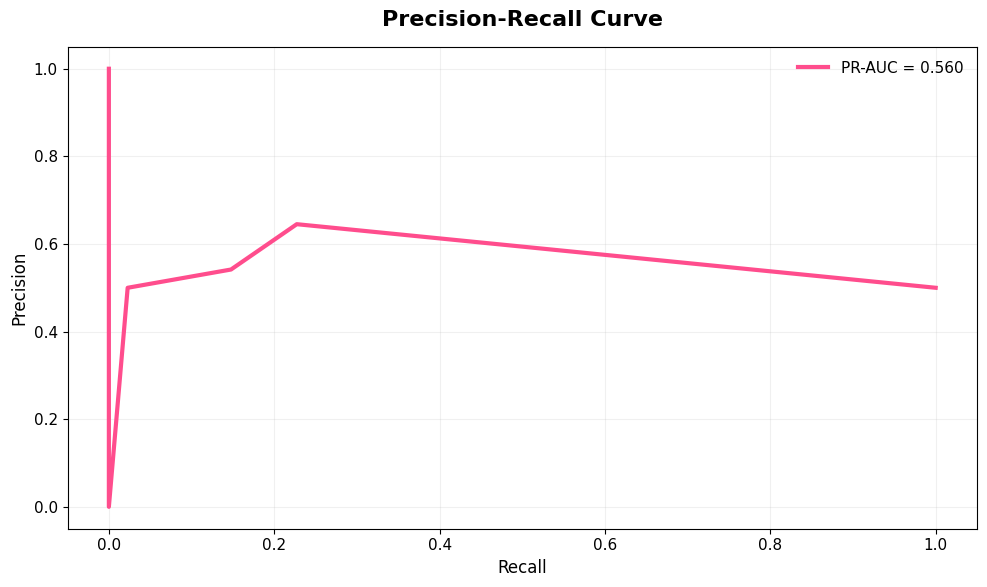

In [15]:
fpr, tpr, _ = roc_curve(y_test, test_probabilities)
roc_auc = auc(fpr, tpr)

precision_curve, recall_curve, _ = precision_recall_curve(y_test, test_probabilities)
pr_auc = auc(recall_curve, precision_curve)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(fpr, tpr, linewidth=3, color=PALETTE["purple"], label=f"GRU ROC-AUC = {roc_auc:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1.8, color="#9E9E9E")
ax.set_title("ROC Curve", pad=15)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(frameon=False)
ax.grid(alpha=0.18)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(recall_curve, precision_curve, linewidth=3, color=PALETTE["pink"], label=f"PR-AUC = {pr_auc:.3f}")
ax.set_title("Precision-Recall Curve", pad=15)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(frameon=False)
ax.grid(alpha=0.18)
plt.tight_layout()
plt.show()

In [16]:
prediction_df = test_df[["text", "sentiment"]].copy()
prediction_df["positive_probability"] = test_probabilities
prediction_df["predicted_sentiment"] = np.where(test_probabilities >= 0.5, "Positive", "Negative")
prediction_df["confidence"] = np.where(
    test_probabilities >= 0.5,
    test_probabilities,
    1 - test_probabilities
)

display(
    prediction_df.sort_values("confidence", ascending=False).head(15)
    .style.format({"positive_probability": "{:.3f}", "confidence": "{:.3f}"})
)

,text,sentiment,positive_probability,predicted_sentiment,confidence
838,The website left me unhappy with the final result. I cannot recommend it in its current form.,Negative,0.496,Negative,0.504
869,The series looked promising but turned out to be a mess. The whole experience became exhausting.,Negative,0.496,Negative,0.504
84,The app was disappointing and frustrating from start to finish. I would not choose it again.,Negative,0.496,Negative,0.504
849,The movie left me unhappy with the final result. I cannot recommend it in its current form.,Negative,0.496,Negative,0.504
424,The phone was surprisingly good and kept getting better. I would happily use it again next week.,Positive,0.496,Negative,0.504
314,"The service was impressive, reliable, and worth the money. I would happily use it again next week.",Positive,0.496,Negative,0.504
462,The service was surprisingly good and kept getting better. I am impressed by how consistent it was.,Positive,0.496,Negative,0.504
282,The movie was beautifully designed and pleasant to use. I would gladly choose it again.,Positive,0.496,Negative,0.504
365,The book worked smoothly and exceeded my expectations. I would happily use it again next week.,Positive,0.496,Negative,0.504
210,The app gave me a genuinely positive experience. It is easy to recommend to other people.,Positive,0.496,Negative,0.504


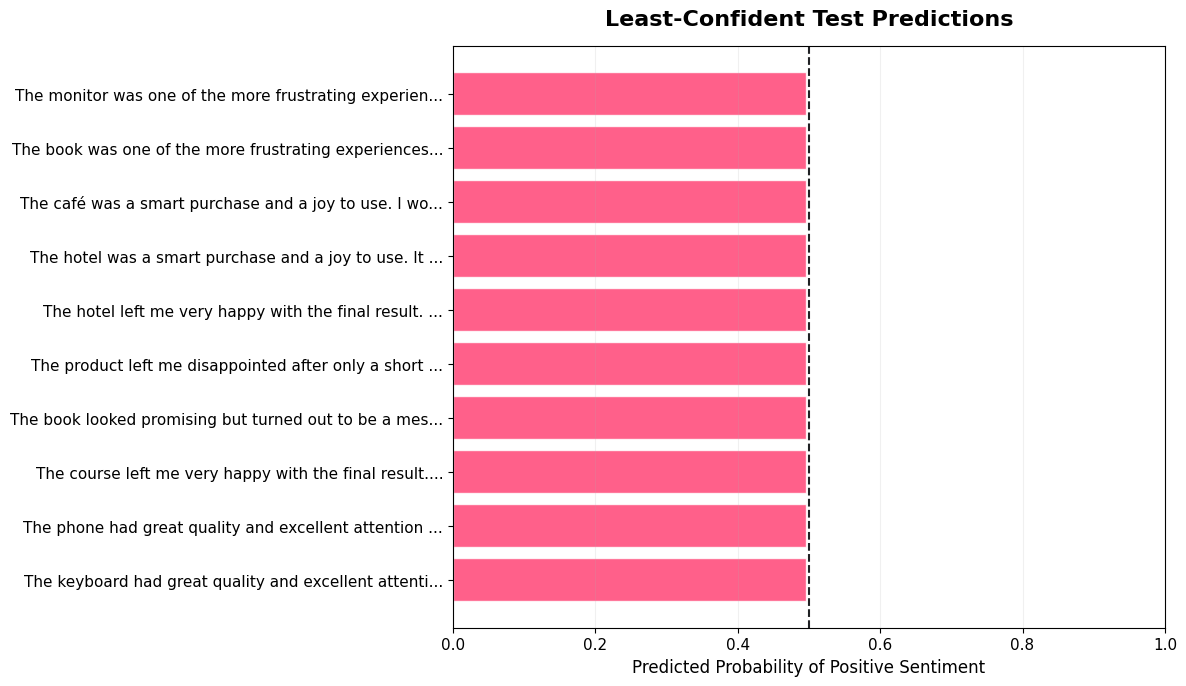

In [17]:
selected = prediction_df.sort_values("confidence").head(10).copy()
selected["display_text"] = selected["text"].str.slice(0, 52) + "..."

fig, ax = plt.subplots(figsize=(12, 7))
positions = np.arange(len(selected))
positive_probability = selected["positive_probability"].values

ax.barh(
    positions,
    positive_probability,
    color=[PALETTE["green"] if p >= 0.5 else PALETTE["red"] for p in positive_probability],
    alpha=0.82,
    edgecolor="white"
)

ax.axvline(0.5, color=PALETTE["dark"], linestyle="--", linewidth=1.5)
ax.set_yticks(positions, selected["display_text"])
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel("Predicted Probability of Positive Sentiment")
ax.set_title("Least-Confident Test Predictions", pad=15)
ax.grid(axis="x", alpha=0.18)
plt.tight_layout()
plt.show()

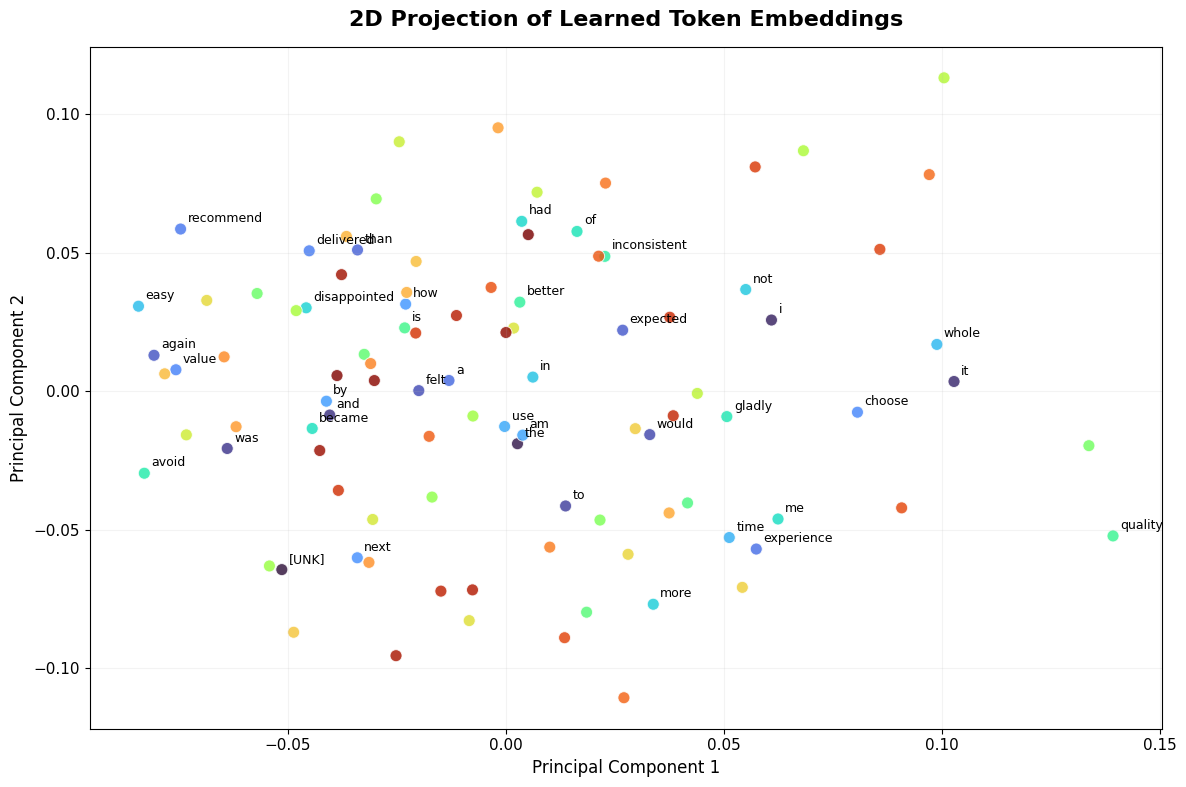

In [18]:
embedding_matrix = model.get_layer("embedding").get_weights()[0]

common_token_ids = np.arange(1, min(len(vocabulary), 101))
embedding_subset = embedding_matrix[common_token_ids]

pca = PCA(n_components=2, random_state=SEED)
embedding_2d = pca.fit_transform(embedding_subset)

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    s=75,
    c=np.arange(len(common_token_ids)),
    cmap="turbo",
    alpha=0.82,
    edgecolors="white",
    linewidths=0.7
)

for idx, token_id in enumerate(common_token_ids[:40]):
    ax.annotate(
        vocabulary[token_id],
        (embedding_2d[idx, 0], embedding_2d[idx, 1]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

ax.set_title("2D Projection of Learned Token Embeddings", pad=15)
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()

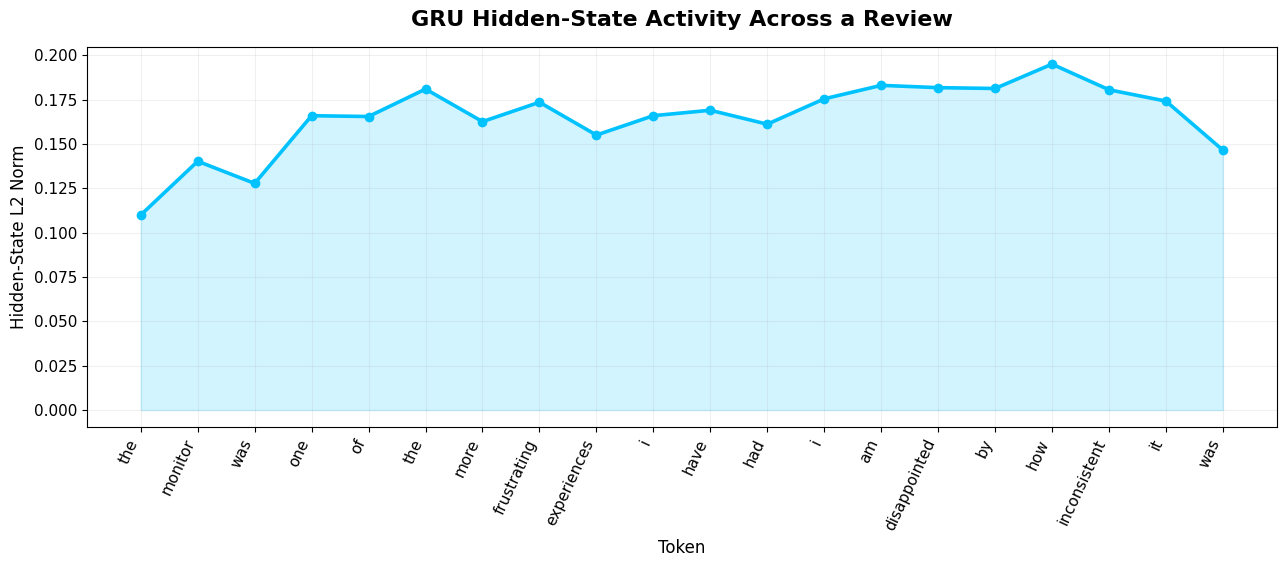

The monitor was one of the more frustrating experiences I have had. I am disappointed by how inconsistent it was.


In [19]:
sequence_model = tf.keras.Model(
    model.input,
    model.get_layer("gru_sequence").output
)

review = X_test[np.argmax(test_probabilities)]
encoded_review = vectorizer(tf.constant([review]))
sequence_states = sequence_model(tf.constant([review])).numpy()[0]
tokens = vectorizer(tf.constant([review])).numpy()[0]
token_names = vocabulary[tokens]

valid_positions = np.where(tokens != 0)[0]
state_norms = np.linalg.norm(sequence_states, axis=1)[valid_positions]
shown_tokens = token_names[valid_positions]

fig, ax = plt.subplots(figsize=(13, 5.8))
ax.plot(
    range(len(shown_tokens)),
    state_norms,
    marker="o",
    linewidth=2.6,
    color=PALETTE["cyan"]
)
ax.fill_between(
    range(len(shown_tokens)),
    state_norms,
    alpha=0.18,
    color=PALETTE["cyan"]
)
ax.set_xticks(range(len(shown_tokens)), shown_tokens, rotation=65, ha="right")
ax.set_title("GRU Hidden-State Activity Across a Review", pad=15)
ax.set_xlabel("Token")
ax.set_ylabel("Hidden-State L2 Norm")
ax.grid(alpha=0.18)
plt.tight_layout()
plt.show()

print(review)

In [20]:
def predict_sentiment(review):
    input_tensor = tf.constant([review], dtype=tf.string)

    probability = float(
        model(input_tensor, training=False).numpy()[0, 0]
    )

    sentiment = "Positive" if probability >= 0.5 else "Negative"

    confidence = (
        probability
        if probability >= 0.5
        else 1 - probability
    )

    return {
        "review": review,
        "sentiment": sentiment,
        "positive_probability": probability,
        "confidence": confidence
    }


custom_reviews = [
    "The experience was smooth, exciting, and far better than I expected.",
    "I regret buying this because it was slow, confusing, and frustrating.",
    "The design is beautiful and the performance is excellent.",
    "This became annoying very quickly and felt like a waste of money."
]


custom_results = pd.DataFrame(
    [predict_sentiment(review) for review in custom_reviews]
)


display(
    custom_results.style.format({
        "positive_probability": "{:.3f}",
        "confidence": "{:.3f}"
    })
)

,review,sentiment,positive_probability,confidence
0,"The experience was smooth, exciting, and far better than I expected.",Negative,0.496,0.504
1,"I regret buying this because it was slow, confusing, and frustrating.",Negative,0.496,0.504
2,The design is beautiful and the performance is excellent.,Negative,0.496,0.504
3,This became annoying very quickly and felt like a waste of money.,Negative,0.496,0.504


In [21]:
error_df = prediction_df[
    prediction_df["sentiment"] != prediction_df["predicted_sentiment"]
].copy()

error_df["error_type"] = np.where(
    error_df["sentiment"] == "Positive",
    "False Negative",
    "False Positive"
)

display(error_df.sort_values("confidence").head(20))

,text,sentiment,positive_probability,predicted_sentiment,confidence,error_type
373,The hotel was a smart purchase and a joy to us...,Positive,0.496343,Negative,0.503657,False Negative
685,The café was a smart purchase and a joy to use...,Positive,0.496343,Negative,0.503657,False Negative
486,The hotel left me very happy with the final re...,Positive,0.496343,Negative,0.503657,False Negative
656,The course left me very happy with the final r...,Positive,0.496343,Negative,0.503657,False Negative
874,The phone had great quality and excellent atte...,Positive,0.496343,Negative,0.503657,False Negative
477,The book left me very happy with the final res...,Positive,0.496343,Negative,0.503657,False Negative
470,The keyboard had great quality and excellent a...,Positive,0.496343,Negative,0.503657,False Negative
472,The service was a wonderful experience from st...,Positive,0.496343,Negative,0.503657,False Negative
847,The series was a wonderful experience from sta...,Positive,0.496343,Negative,0.503657,False Negative
296,The delivery had great quality and excellent a...,Positive,0.496343,Negative,0.503657,False Negative


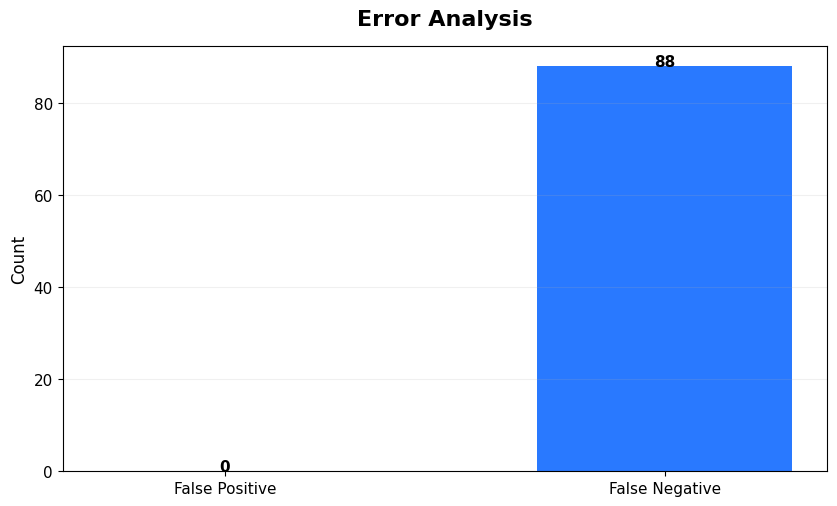

In [22]:
error_counts = error_df["error_type"].value_counts().reindex(
    ["False Positive", "False Negative"],
    fill_value=0
)

fig, ax = plt.subplots(figsize=(8.5, 5.2))
bars = ax.bar(
    error_counts.index,
    error_counts.values,
    color=[PALETTE["orange"], PALETTE["blue"]],
    width=0.58
)
ax.set_title("Error Analysis", pad=15)
ax.set_ylabel("Count")
ax.grid(axis="y", alpha=0.18)

for bar, value in zip(bars, error_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.1, str(value), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

In [23]:
import os

final_model_path = "/content/gru_sentiment_model.keras"

model.save(final_model_path)

print("Model saved successfully:")
print(final_model_path)
print("File exists:", os.path.exists(final_model_path))

Model saved successfully:
/content/gru_sentiment_model.keras
File exists: True


In [24]:
summary = pd.DataFrame({
    "Item": [
        "Dataset size",
        "Vocabulary size",
        "Sequence length",
        "Embedding dimension",
        "GRU units",
        "Test accuracy",
        "Test precision",
        "Test recall",
        "Test F1",
        "Test ROC-AUC"
    ],
    "Value": [
        len(df),
        len(vocabulary),
        SEQUENCE_LENGTH,
        embedding_dim,
        gru_units,
        metrics["Accuracy"],
        metrics["Precision"],
        metrics["Recall"],
        metrics["F1"],
        metrics["ROC-AUC"]
    ]
})

display(summary.style.format({
    "Value": lambda x: f"{x:.4f}" if isinstance(x, (float, np.floating)) else x
}))

,Item,Value
0,Dataset size,880.0000
1,Vocabulary size,255.0000
2,Sequence length,45.0000
3,Embedding dimension,64.0000
4,GRU units,64.0000
5,Test accuracy,0.5000
6,Test precision,0.0000
7,Test recall,0.0000
8,Test F1,0.0000
9,Test ROC-AUC,0.5456
